In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 各パス指定

In [2]:
dataset = 'model/point_history_classifier/point_history.csv'
model_save_path = 'model/point_history_classifier/point_history_classifier.keras'

# 分類数設定

In [3]:
NUM_CLASSES = 5

# 入力長

In [4]:
TIME_STEPS = 8 # 8 green circles each finger tip
DIMENSION = 10 # 2 values (x,y) for each of the 5 fingers = 2*5 = 10

# 学習データ読み込み

In [5]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (TIME_STEPS * DIMENSION) + 1)))
# each line of the dataset point_history.csv starts with the finger number 0-4 followed by 160 values

In [6]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)
# train_size=0.75 means 75% of input data is used for training, while 25% is used later for validation

# モデル構築

In [ ]:
arch = "Transformer"
# options:
#   FC (fully connected)
#   CNN (Convolutional Neural Network)
#   Transformer [by default]
model = None

if arch == "FC":
    model = tf.keras.models.Sequential([
            tf.keras.layers.InputLayer(input_shape=(TIME_STEPS * DIMENSION, )),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(24, activation='relu'),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(10, activation='relu'),
            tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
        ])
elif arch == "CNN":
    model = tf.keras.models.Sequential([
        # 1. Original flat input: (TIME_STEPS * DIMENSION)
        tf.keras.layers.InputLayer(input_shape=(TIME_STEPS * DIMENSION, )),
            
        # 2. Key reshape: transforms data into (TIME_STEPS = )8 time steps (the frames).
        # Each frame contains all x,y coordinates of your points (DIMENSION)
        tf.keras.layers.Reshape((TIME_STEPS, DIMENSION)), 
        tf.keras.layers.Dropout(0.2),
            
        # 3. First Conv1D block: analyzes relationships between points within the same frame
        # and across adjacent frames (temporal window of 3 frames)
        tf.keras.layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'),
        # Reduces the temporal dimension by half (from 8 frames to 4)
        tf.keras.layers.MaxPooling1D(pool_size=2),
            
        # 4. Second Conv1D block: extracts more complex movement patterns
        tf.keras.layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
        # Reduces the time dimension further (from 4 frames to 2)
        tf.keras.layers.MaxPooling1D(pool_size=2),
            
        # 5. Flattening and classification (identical to your original structure)
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
else:
    # Usiamo le Functional API di Keras poiché i Transformer richiedono connessioni residue (skip connections)
    inputs = tf.keras.layers.Input(shape=(TIME_STEPS * DIMENSION, ))
    
    # 1. Reshape in (TIME_STEPS, DIMENSION)
    x = tf.keras.layers.Reshape((TIME_STEPS, DIMENSION))(inputs)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    # 2. Layer di Self-Attention (il cuore del Transformer)
    # Calcola le relazioni tra i diversi frame temporali
    attention_output = tf.keras.layers.MultiHeadAttention(
        num_heads=4, key_dim=DIMENSION
    )(query=x, value=x, key=x)
    
    # 3. Connessione residua e Normalizzazione
    x = tf.keras.layers.Add()([x, attention_output])
    x = tf.keras.layers.LayerNormalization()(x)
    
    # 4. Riduzione della dimensionalità e classificazione
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(10, activation='relu')(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs)

C:\Users\Acer\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [9]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout (Dropout)                    │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 24)                  │           1,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │              55 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,249 (8.79 KB)

 Trainable params: 2,249 (8.79 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [11]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [12]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test), # (see above) 25% of data is used for validation
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.1797 - loss: 1.6033
Epoch 1: saving model to model/point_history_classifier/point_history_classifier.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 0.2139 - loss: 1.5979 - val_accuracy: 0.2381 - val_loss: 1.5888
Epoch 2/1000
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.2109 - loss: 1.5960
Epoch 2: saving model to model/point_history_classifier/point_history_classifier.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.2406 - loss: 1.5957 - val_accuracy: 0.2381 - val_loss: 1.5830
Epoch 3/1000
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2734 - loss: 1.5822
Epoch 3: saving model to model/point_history_classifier/point_history_classifier.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.2460 - loss: 1.5989 - val_accuracy: 0.2540 - val_loss: 1.5770
Epoch 4/1000
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2031 - loss: 1.5670
Epoch 4: saving model to model/point_history_classifier/

In [13]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [14]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
[6.5795291e-04 9.7012982e-02 7.2879737e-07 8.9287835e-01 9.4499243e-03]
3


# 混同行列

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


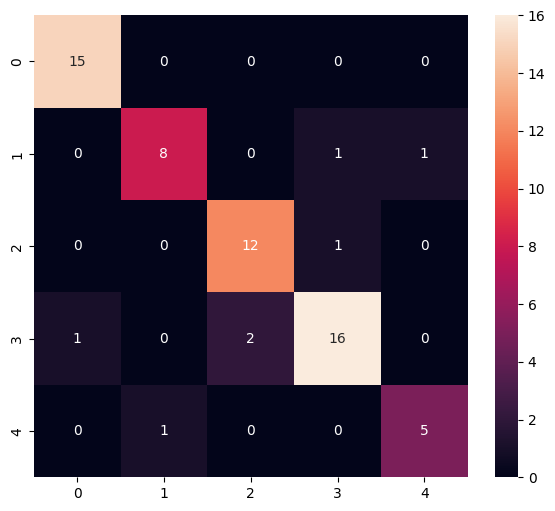

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       0.89      0.80      0.84        10
           2       0.86      0.92      0.89        13
           3       0.89      0.84      0.86        19
           4       0.83      0.83      0.83         6

    accuracy                           0.89        63
   macro avg       0.88      0.88      0.88        63
weighted avg       0.89      0.89      0.89        63



In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)
# horizontal axis: real class
# vertical axis: predicted class
# on the diagonal true predictions, other areas are false predictions

# Tensorflow-Lite用のモデルへ変換

In [16]:
# 推論専用のモデルとして保存
 # old but what metters? you can keep it
#model.save(model_save_path, include_optimizer=False)
#model = tf.keras.models.load_model(model_save_path)

In [17]:
tflite_save_path = 'model/point_history_classifier/point_history_classifier.tflite'

In [18]:
# モデルを変換(量子化
converter = tf.lite.TFLiteConverter.from_keras_model(model)  # converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
#converter.optimizations = [tf.lite.Optimize.DEFAULT] #old, try again this but nothing
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\Acer\AppData\Local\Temp\tmppmcezgwn\assets


INFO:tensorflow:Assets written to: C:\Users\Acer\AppData\Local\Temp\tmppmcezgwn\assets


Saved artifact at 'C:\Users\Acer\AppData\Local\Temp\tmppmcezgwn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 80), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2320462521520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320462524864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320468174880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320487571776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320487572480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320468952336: TensorSpec(shape=(), dtype=tf.resource, name=None)


11184

# 推論テスト

In [19]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

C:\Users\Acer\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [20]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print(input_details)

[{'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([ 1, 80], dtype=int32), 'shape_signature': array([-1, 80], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


In [21]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [22]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [23]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[6.5795286e-04 9.7013086e-02 7.2879646e-07 8.9287823e-01 9.4499318e-03]
3
